# Demo Notebook
[paper](https://openreview.net/forum?id=hkF7ZM7fEp&referrer=%5BAuthor%20Console%5D(%2Fgroup%3Fid%3DICLR.cc%2F2026%2FConference%2FAuthors%23your-submissions) | [blog](https://mansisak.com/operator_aliasing/) | [code](https://github.com/msakarvadia/operator_aliasing)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import ticker
from matplotlib.colors import LogNorm
from torchvision import transforms

data_folder = "/pscratch/sd/m/mansisak/PDEBench/pdebench_data/2D/DarcyFlow/" # replace with your file path
file_name = "2D_DarcyFlow_beta1.0_Train.hdf5"
initial_steps = 1 # 1 timestep for Darcy flow (change for time varying datasets)

FIG_DIR = '../figures'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Utils

In [2]:
def get_energy_curve(
    data: torch.Tensor, normalize: bool = True
) -> torch.Tensor:
    """Calculate 2d spectrum of data.

    data dim: batch x time x X x Y
    """
    signal = data.cpu()
    batch_size = signal.shape[0]
    time_points = signal.shape[1]
    n_observations = signal.shape[-1]
    signal = signal.view(
        batch_size, time_points, n_observations, n_observations
    )

    if normalize:
        signal = torch.fft.fft2(signal, norm='ortho')
    else:
        signal = torch.fft.rfft2(
            signal, s=(n_observations, n_observations), norm='backward'
        )

    # center FFT
    centered_fft_signal = torch.fft.fftshift(signal)

    # compute energy
    energy = centered_fft_signal.abs() ** 2

    # define wavenumbers
    wave_numbers = generate_wavenumbers(n=n_observations)
    max_wavenumber = n_observations // 2

    spectrum = torch.zeros((batch_size, time_points, n_observations // 2))
    for j in range(1, max_wavenumber + 1):
        ind = torch.where(torch.tensor(wave_numbers) == j)
        spectrum[:, :, j - 1] = energy[:, :, ind[0], ind[1]].sum(dim=-1)

    time_avg_spectrum = spectrum.mean(dim=1)
    batch_avg_spectrum = time_avg_spectrum.mean(dim=0)
    return batch_avg_spectrum

def get_model_preds(
    test_loader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    device: torch.device,
    initial_steps: int,
    # data_transform: DataProcessor,
) -> torch.Tensor:
    """Return model predictions."""
    model_preds = []
    model = model.to(device)
    with torch.no_grad():
        for _idx, sample in enumerate(test_loader):  # resolution 128
            model_input = sample['x'][0].to(device)
            model_output = sample['y'][0].to(device)
            with torch.no_grad():
                if initial_steps > 1:
                    out = autoregressive_inference(
                        initial_steps, model, model_input, model_output
                    )
                else:
                    out = model(model_input)
                model_preds.append(out)
    return torch.cat(model_preds)

def generate_wavenumbers(n: int = 6) -> torch.tensor:
    """Generate the wavenumbers."""
    # n = 7  # Size of the square array
    center = n // 2  # Center of the array
    array = np.zeros((n, n), dtype=int)

    # Fill values based on distance from the center
    for i in range(n):
        for j in range(n):
            distance = max(abs(center - i), abs(center - j))
            array[i, j] = distance

    # For even-sized arrays, ensure the center area avoids 0 directly
    if n % 2 == 0:
        for i in range(n):
            for j in range(n):
                if i + j >= n:
                    array[i, j] += 1
    return array
    
def get_energy_curve(
    data: torch.Tensor, normalize: bool = True
) -> torch.Tensor:
    """Calculate 2d spectrum of data.

    data dim: batch x time x X x Y
    """
    signal = data.cpu()
    batch_size = signal.shape[0]
    time_points = signal.shape[1]
    n_observations = signal.shape[-1]
    signal = signal.view(
        batch_size, time_points, n_observations, n_observations
    )

    if normalize:
        signal = torch.fft.fft2(signal, norm='ortho')
    else:
        signal = torch.fft.rfft2(
            signal, s=(n_observations, n_observations), norm='backward'
        )

    # center FFT
    centered_fft_signal = torch.fft.fftshift(signal)

    # compute energy
    energy = centered_fft_signal.abs() ** 2

    # define wavenumbers
    wave_numbers = generate_wavenumbers(n=n_observations)
    max_wavenumber = n_observations // 2

    spectrum = torch.zeros((batch_size, time_points, n_observations // 2))
    for j in range(1, max_wavenumber + 1):
        ind = torch.where(torch.tensor(wave_numbers) == j)
        spectrum[:, :, j - 1] = energy[:, :, ind[0], ind[1]].sum(dim=-1)

    time_avg_spectrum = spectrum.mean(dim=1)
    batch_avg_spectrum = time_avg_spectrum.mean(dim=0)
    return batch_avg_spectrum

# Data

Download Darcy Dataset from PDEBench: https://github.com/pdebench/PDEBench/tree/main/pdebench/data_download

#### Transformations

In [3]:
"""Transforms to apply to data prior to training."""

from __future__ import annotations

import typing

import torch
import torch.nn.functional as f

def filter_batch(
    filt: torch.tensor, batch: torch.tensor, ndim: int
) -> torch.Tensor:
    """Apply (low-pass) filter to batch.

    filt:
            filter for the batch
            (already centered i.e., torch.fft.fftshift)
            dim: (channel x X_dim x Y_dim) 2D
    batch:
            input batch
            dim: (batch x channel x X_dim x Y_dim ) 2D
    ndim:
            number of spatial dimentions

    """
    dim: typing.Any = (-2, -1)
    if ndim == 1:
        dim = -1
    # fft batch
    batch_fourier = torch.fft.fftn(batch, dim=dim)

    # center batch
    fourier_centered = torch.fft.fftshift(batch_fourier)

    # apply filter
    filtered_batch = fourier_centered * filt

    # convert batch back to spatial domain
    filtered_batch = torch.real(
        torch.fft.ifftn(torch.fft.ifftshift(filtered_batch), dim=dim)
    )

    return filtered_batch

def generate_wavenumbers(n: int = 6) -> torch.tensor:
    """Generate the wavenumbers."""
    # n = 7  # Size of the square array
    center = n // 2  # Center of the array
    array = np.zeros((n, n), dtype=int)

    # Fill values based on distance from the center
    for i in range(n):
        for j in range(n):
            distance = max(abs(center - i), abs(center - j))
            array[i, j] = distance

    # For even-sized arrays, ensure the center area avoids 0 directly
    if n % 2 == 0:
        for i in range(n):
            for j in range(n):
                if i + j >= n:
                    array[i, j] += 1
    return array
    
def get_2d_low_pass_filter(f: int, s: int) -> torch.Tensor:
    """Return's low pass filter at limit f and size s.

    f : the frequency limit (only allow freq < f)
    s : dimention of image
    """
    if f > s // 2:
        raise Exception(f'Max frequency of image is {s//2=}, so lower f')
    # 1 = keep, 0 = get rid of
    # central of shifted FFT image is lowest freqs
    wave_numbers = generate_wavenumbers(s)

    filt = torch.where(torch.tensor(wave_numbers) < f, 1, 0)
    return filt.unsqueeze(dim=0)


class LowpassFilter:
    """Lowpass filter the image.

    Args:
        filter_limit: frequencies > filter_lim excluded
    """

    def __init__(self, filter_limit: int, n_dim: int) -> None:
        """Initialize filter transform.

        filter_limit: number of frequencies to keep
        n_dim: number of spatial dimentions
            typically you use n_dim to choose filter dim (1d v. 2d)
            here we simplify and only have 2d filter (see repo for more options)
        """
        assert isinstance(filter_limit, int)
        self.filter_limit = filter_limit
        self.n_dim = n_dim

    def __call__(
        self, sample: dict[str, torch.Tensor]
    ) -> dict[str, torch.Tensor]:
        """Apply transform."""
        model_input, label = sample['x'], sample['y']
        img_size = model_input.shape[-1]
        # assert that filter limit is less than half img_size
        assert self.filter_limit <= img_size // 2

        # get filter
        self.filter = get_2d_low_pass_filter(self.filter_limit, img_size)

        # apply no filter
        if self.filter_limit == -1:
            return sample

        filter_input = filter_batch(self.filter, model_input, self.n_dim)
        filter_label = filter_batch(self.filter, label, self.n_dim)

        sample['x'] = filter_input
        sample['y'] = filter_label
        return sample


class DownSample:
    """Downsize image.

    Args:
        out_size: x/y dim of downsampled obj
    """

    def __init__(self, out_size: int, n_dim: int) -> None:
        """Initialize downsample transform.

        outsize: resized spatial dim
        n_dim: number of spatial dims
        """
        assert isinstance(out_size, int)
        self.out_size = out_size
        self.n_dim = n_dim

    def __call__(
        self, sample: dict[str, torch.Tensor]
    ) -> dict[str, torch.Tensor]:
        """Apply transform."""
        model_input, label = sample['x'], sample['y']

        # apply no downsample
        if self.out_size == -1:
            return sample

        # desired spatial dim
        shape = tuple([self.out_size] * self.n_dim)
        # store dimention for post downsample batch/channel/time dim
        input_post_shape = model_input.shape[: -self.n_dim] + shape
        label_post_shape = label.shape[: -self.n_dim] + shape

        pre_shape: typing.Any = (model_input.shape[0], -1)
        for _dim in range(self.n_dim):
            pre_shape += (model_input.shape[-1],)

        # collapse time and channel dim if it exists
        model_input = torch.reshape(model_input, pre_shape)
        label = torch.reshape(label, pre_shape)

        antialias = self.n_dim > 1
        mode = 'bicubic' if self.n_dim > 1 else 'linear'
        downsample_input = f.interpolate(
            model_input,
            size=shape,
            mode=mode,
            antialias=antialias,
        )

        downsample_label = f.interpolate(
            label,
            size=shape,
            mode=mode,
            antialias=antialias,
        )
        # uncollapse time and channel dims if they existed
        sample['x'] = torch.reshape(downsample_input, input_post_shape)
        sample['y'] = torch.reshape(downsample_label, label_post_shape)
        return sample

#### Data loading

In [4]:
import math
import typing
from pathlib import Path

import h5py
import numpy as np
import torch
from numpy.random import default_rng
from torch.utils.data import Dataset
from torchvision.transforms import Compose

# https://github.com/pdebench/PDEBench/blob/main/pdebench/models/fno/utils.py

class DarcyPDEBench(Dataset):
    """Darcy Dataset from PDE Bench."""

    def __init__(
        self,
        filename: str,
        saved_folder: str = '../data/',
        train: bool = True,
        transform: Compose = None,
        resolution_proportions: list[float]=[1,0,0,0],
        **kwargs,
    ):
        """Initialize data.

        :param filename: filename that contains the dataset
        :type filename: STR
        :saved folder: path to PDE bench data
        : train: bool (True = train, False=Test)
        : transforms: Any torch transforms (we will define downsampling/filtering transforms)
        : resolution_proportions: must sum to 1. Fraction of dataset for resolutions [128,64,32,16]
            [1,0,0,0] == 100% 128 res
            [0,0.5,0.5,0] == 50% 64, 50% 32
        support img dimentions: 128, 64, 32, 16 (highest to lowest)
        """
        self.transform = transform

        four = 4
        assert len(resolution_proportions) == four, (
            'Only support 4 img_resolutions, see doc string.'
        )
        assert sum(resolution_proportions) == 1, (
            'All dataset proportions must sum to 1.'
        )
        self.rng = default_rng(seed=0)
        self.batch_size = 128
        test_ratio = 0.1
        num_samples_max = -1

        # Define path to files
        self.model_inputs = []
        self.labels = []
        root_path = Path(Path(saved_folder).resolve()) / filename
        # preprocessing for train/test sets and
        # ...initializing/shuffling data indexes
        with h5py.File(root_path, 'r') as f:
            # num of data samples
            num_samples_max = f['tensor'].shape[0]

            # list of data idxs
            data_idx = np.arange(0, num_samples_max)
            # num of test samples
            test_idx = int(num_samples_max * test_ratio)
            if train:
                first_batch_idx = test_idx
                last_batch_idx = -1
                self.num_samples = num_samples_max - test_idx
            else:
                first_batch_idx = 0
                last_batch_idx = test_idx
                self.num_samples = test_idx
            print(f'{self.num_samples=}')
            # grab data indexs
            self.data_idxs = data_idx[first_batch_idx:last_batch_idx]
            # shuffle indexes
            self.rng.shuffle(self.data_idxs)

        for res_factor, ratio in enumerate(resolution_proportions):
            reduced_resolution = 2**res_factor
            with h5py.File(root_path, 'r') as f:
                # number of points in this resolution set
                res_idx = int(self.num_samples * ratio)
                # sort all indexes
                set_indexes = np.sort(self.data_idxs[:res_idx])
                # u: label
                label = np.array(
                    f['tensor'][
                        set_indexes,
                        :,
                        ::reduced_resolution,
                        ::reduced_resolution,
                    ],
                    dtype=np.float32,
                )

                # batch, time, x,...
                _data = np.array(f['nu'], dtype=np.float32)
                # nu: input
                model_input = _data[
                    set_indexes,
                    None,
                    ::reduced_resolution,
                    ::reduced_resolution,
                ]

                self.model_inputs.append(torch.tensor(model_input))
                self.labels.append(torch.tensor(label))

                # remove already used indexes
                self.data_idxs = self.data_idxs[res_idx:]

    def __len__(self) -> int:
        """Returns len of dataset.

        Recall this is a pre-batched dataset, so we return
        number of batches.
        """
        total_batches = 0
        for _set_idx, res_set in enumerate(self.model_inputs):
            num_batches_in_set = math.ceil(len(res_set) / self.batch_size)
            total_batches += num_batches_in_set
        return total_batches

    def __getitem__(self, batch_idx: int) -> dict[str, torch.Tensor]:
        """Get single sample at idx."""
        # iterate through all resoulution sets to find batch
        for _set_idx, res_set in enumerate(self.model_inputs):
            num_batches_in_set = math.ceil(len(res_set) / self.batch_size)
            if batch_idx >= num_batches_in_set:
                batch_idx -= num_batches_in_set
            else:
                item_idx = int(batch_idx * self.batch_size)
                set_idx = _set_idx
                break

        # return whole batch, not just single datapoint
        sample = {
            'x': self.model_inputs[set_idx][
                item_idx : item_idx + self.batch_size
            ],
            'y': self.labels[set_idx][item_idx : item_idx + self.batch_size],
        }
        if self.transform:
            sample = self.transform(sample)
        return sample

In [5]:
from torch.utils.data import DataLoader
def get_data(
    **data_args: typing.Any,
) -> tuple[DataLoader, dict[str, DataLoader]]:
    """Get data w/ args."""
    seed = 0
    g = torch.Generator()
    g.manual_seed(seed)

    # set train specific kwarg
    data_args['train'] = True
    train_dataset = DarcyPDEBench(**data_args)

    test_datasets = {}

    # NOTE(MS): single dataset standard
    # intended use: HP search, filter/downsample exp
    test_kwargs = data_args
    test_kwargs['train'] = False
    if test_kwargs['test_res'] == 'single':
        test_dataset = DarcyPDEBench(**test_kwargs)
        test_datasets['test'] = test_dataset

    # multiple test_datasets
    # NOTE(MS): (this may not work w/ multiple downsample/filter regeims)
    # intended us: multi-res training testing
    if test_kwargs['test_res'] == 'multi':
        for res in range(4):
            resolution_ratios = [0, 0, 0, 0]
            resolution_ratios[res] = 1
            test_kwargs['resolution_ratios'] = resolution_ratios
            test_dataset = DarcyPDEBench(**test_kwargs)
            test_datasets[f'test_res_{res}'] = test_dataset

    training_loader = DataLoader(
        train_dataset,
        batch_size=1,
        shuffle=True,
        generator=g,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
    )

    testing_loaders = {}
    for k, test_dataset in test_datasets.items():
        testing_loaders[k] = DataLoader(
            test_dataset,
            batch_size=1,
            shuffle=False,
            generator=g,
            num_workers=8,
            pin_memory=True,
            persistent_workers=True,
        )
    return (training_loader, testing_loaders)

In [6]:
# This is how we graph a train dataset of resolution 128 and test datasets of resolution [128,64,32,16]
train_loader, test_loaders = get_data(filename=file_name,
        saved_folder=data_folder,
        transform=None, 
        resolution_proportions=[1,0,0,0],
        test_res="multi")

self.num_samples=9000
self.num_samples=1000
self.num_samples=1000
self.num_samples=1000
self.num_samples=1000


# Model

In [7]:
from neuralop.models import FNO
def get_fno(n_modes):
    starting_modes = (n_modes, n_modes)
    model = FNO(
        n_modes=starting_modes,
        hidden_channels=32,
        in_channels=1,
        out_channels=1,
    )
    return model

get_fno(n_modes=8)

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([32, 32, 8, 5]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(32, 16, kernel_size=(1,), stride=(1,))
          (1): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 1, kernel_size=(1

# Train/Test Utils

In [8]:
from torch.nn import Module
from torch.optim import AdamW
from tqdm import tqdm
def train_model(model, train_dataloader, test_dataloaders) -> Module:
    """Train a model."""
    # set up trianing args
    epochs = 150
    loss = nn.MSELoss()

    # set up optimizer and scheduler
    optimizer = AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=0.00001,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=50, gamma=0.5
    )
    starting_epoch = 0
    model = model.to(device)

    # train model
    pbar = tqdm(range(starting_epoch, epochs + 1), desc="Training")
    #for epoch in tqdm(range(starting_epoch, epochs + 1), desc="Training"):
    for epoch in pbar:
        train_loss = 0.0
        # timing to exclude potential data loading
        forward_back_time = 0.0
        for _step, batch in enumerate(train_dataloader):
            # NOTE(MS): must remove outer batch dim from dataloader
            # because we pre-batch data due to multi-res training
            input_batch = batch['x'][0].to(device)
            output_batch = batch['y'][0].to(device)
            batch['device'] = device

            optimizer.zero_grad()

            output_pred_batch = model(input_batch)
            loss_f = loss(
                output_pred_batch, output_batch
            )

            loss_f.backward()
            optimizer.step()
            train_loss += loss_f.item()
        train_loss /= len(train_dataloader)
        scheduler.step()
        # test model
        test_dict = test_model(
            model,
            test_dataloaders,
            device,
        )
        pbar_str =f"{train_loss:.1}"
        for key in test_dict.keys():
            pbar_str+=f" {key}={test_dict[key]:.1}"
        pbar.set_postfix(train_loss=pbar_str)

    return model.to('cpu')

def test_model(
    model: Module,
    test_dataloaders: dict[str, torch.utils.data.DataLoader],
    device: torch.device,
) -> dict[str, float]:
    """Test model."""
    test_dict = {}
    loss = nn.MSELoss()
    with torch.no_grad():
        model.eval()
        for test_label, test_dataloader in test_dataloaders.items():
            test_relative_l2 = 0.0
            for _step, batch in enumerate(test_dataloader):
                # NOTE(MS): must remove outer batch dim from dataloader
                # because we pre-batch data due to multi-res training
                input_batch = batch['x'][0].to(device)
                output_batch = batch['y'][0].to(device)
                batch['device'] = device

                output_pred_batch = model(input_batch)
                loss_f = loss(
                    output_pred_batch,
                    output_batch,
                )

                test_relative_l2 += loss_f.item()
            test_relative_l2 /= len(test_dataloader)
            test_dict[test_label] = test_relative_l2
    return test_dict

# Zero-shot super-resolution

Train a model @ resolution 16, test at resoluitons [16,32,64,128].
Visualize the average spectra across all 4 test sets.

In [9]:
model = get_fno(n_modes=8)
train_dataloader, test_dataloaders = get_data(filename=file_name,
        saved_folder=data_folder,
        transform=None, 
        resolution_proportions=[0,0,0,1],
        test_res="multi")

model = train_model(model, train_dataloader, test_dataloaders)

self.num_samples=9000
self.num_samples=1000
self.num_samples=1000
self.num_samples=1000
self.num_samples=1000


Training: 100%|██████████| 151/151 [01:57<00:00,  1.29it/s, train_loss=0.0002 test_res_0=0.0004 test_res_1=0.0004 test_res_2=0.0004 test_res_3=0.0004]


self.num_samples=1000


/tmp/ipykernel_71525/671154304.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zero_shot_aucs.append(abs(np.trapz(x, normalized_residuals).item()))


self.num_samples=1000
self.num_samples=1000
self.num_samples=1000


/tmp/ipykernel_71525/671154304.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


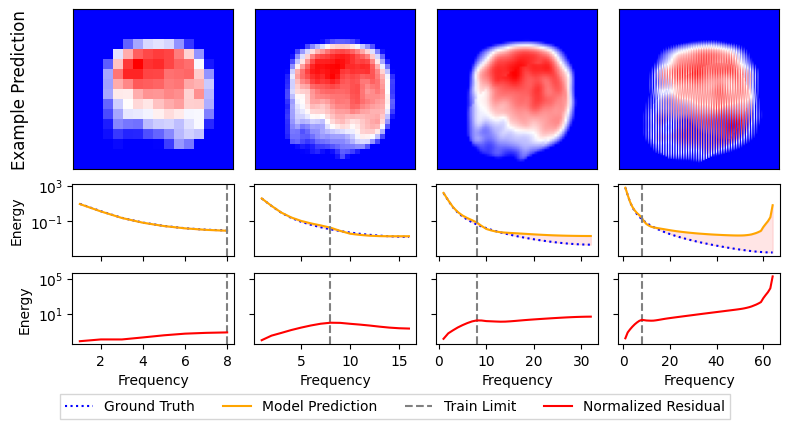

In [10]:
# fig, axs = plt.subplots(3, 4, figsize=(8, 8))

fig = plt.figure(layout='constrained', figsize=(8, 3.5))
subfigs = fig.subfigures(2, 1, wspace=0.07)  # three rows

img_axs = subfigs[0].subplots(1, 4, sharey=False)
spectrum_axs = subfigs[1].subplots(2, 4, sharey='row', sharex='col', gridspec_kw={'height_ratios': [1, 1]})
model = model.to(device)
model = model.eval()
zero_shot_aucs = []

for x_idx, res in enumerate([16, 32, 64, 128]):
    resolution_ratio = [0, 0, 0, 0]
    resolution_ratio[-(x_idx + 1)] = 1
    resolutions = [16, 32, 64, 128]  # [128, 64, 32, 16]
    dataset = DarcyPDEBench(filename=file_name,
        saved_folder=data_folder,
        train=False,
        transform=None, 
        resolution_proportions=resolution_ratio,
        )
    # sample = dataset[0]
    sample = {
        'x': torch.concat([dataset[i]['x'] for i in range(len(dataset))]),
        'y': torch.concat([dataset[i]['y'] for i in range(len(dataset))]),
    }
    # grab a single input from the last batch
    model_input = sample['x'].to(device) 
    with torch.no_grad():
        model_output = model(x=model_input)
    ground_truth = sample['y']
    residuals = model_output - ground_truth.to(
        device
    )  

    # convert to plotable form
    model_in = model_input[0, 0, :, :].cpu().numpy()
    output = model_output[0, 0, :, :].cpu().numpy()
    label = ground_truth[0, 0, :, :].cpu().numpy()

    # get spectrums
    label_spectrum = get_energy_curve(ground_truth)
    pred_spectrum = get_energy_curve(model_output)
    residual_spectrum = get_energy_curve(residuals)

    img = output  # - label
    norm = colors.LogNorm(img.mean() + 0.5 * img.std(), img.max(), clip='True')
    img_axs[x_idx].imshow(img, norm=norm, cmap='bwr')

    img_axs[x_idx].get_yaxis().set_visible(False)
    img_axs[x_idx].get_xaxis().set_visible(False)
    subfigs[0].supylabel('Example Prediction')

    spectrum_axs[0,x_idx].set_yscale('log')
    spectrum_axs[1,x_idx].set_yscale('log')
    x = np.linspace(1, len(label_spectrum), len(label_spectrum))
    spectrum_axs[0,x_idx].plot(x, label_spectrum, label='Ground Truth', color="blue", ls=":")
    spectrum_axs[0,x_idx].plot(x, pred_spectrum, label='Model Prediction', color="orange")
    spectrum_axs[0,x_idx].fill_between(x, label_spectrum, pred_spectrum, color='red', alpha=0.1)
    spectrum_axs[0,x_idx].axvline(x=8, color='gray', linestyle='--', label="Train Limit")
    spectrum_axs[1,x_idx].axvline(x=8, color='gray', linestyle='--',) 
    normalized_residuals = residual_spectrum / label_spectrum
    spectrum_axs[1,x_idx].plot(
        x,
        normalized_residuals,
        label='Normalized Residual',
        color='red',
    )
    spectrum_axs[0, 0].set_ylabel('Energy')
    spectrum_axs[1, 0].set_ylabel('Energy')
    spectrum_axs[1,x_idx].xaxis.set_major_locator(
        ticker.MaxNLocator(integer=True, nbins=4)
    )
    spectrum_axs[1,x_idx].set_xlabel('Frequency')
    zero_shot_aucs.append(abs(np.trapz(x, normalized_residuals).item()))


handles, labels = spectrum_axs[0,x_idx].get_legend_handles_labels()
_handles, _labels = spectrum_axs[1,x_idx].get_legend_handles_labels()
handles = handles + _handles
labels = labels + _labels
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fancybox=False,
    shadow=False,
    ncol=9,
)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/zero_{device}.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Resolution Interpolation

Filter before downsampling. Assessing if models can accuratly interpolate points in data that has fixed frequency information.

In [12]:
fixed_lim = 8 # filter limit
downsample_dims = [16, 32, 64, -1] # data downsampled resoutions: 16, 32, 64, 128
img_size = 128
max_modes = [
    img_size // 16,
    img_size // 8,
    img_size // 4,
    img_size // 2,
]

trained_models = []
for max_mode, downsample_dim in zip(max_modes, downsample_dims):
    # Handle data transformations
    data_transforms = transforms.Compose(
        [
            LowpassFilter(fixed_lim, 2),
            DownSample(downsample_dim, 2),
        ]
    )

    train_dataloader, test_dataloaders = get_data(filename=file_name,
        saved_folder=data_folder,
        transform=data_transforms, 
        resolution_proportions=[1,0,0,0],
        test_res="single")

    model = get_fno(n_modes=max_mode)
    model = train_model(model, train_dataloader, test_dataloaders)
    trained_models.append(model)

self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [07:10<00:00,  2.85s/it, train_loss=0.0001 test=0.0003]


self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [07:15<00:00,  2.88s/it, train_loss=7e-05 test=0.0004] 


self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [08:07<00:00,  3.23s/it, train_loss=7e-05 test=0.0004] 


self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [23:07<00:00,  9.19s/it, train_loss=8e-05 test=0.0004] 


self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_s

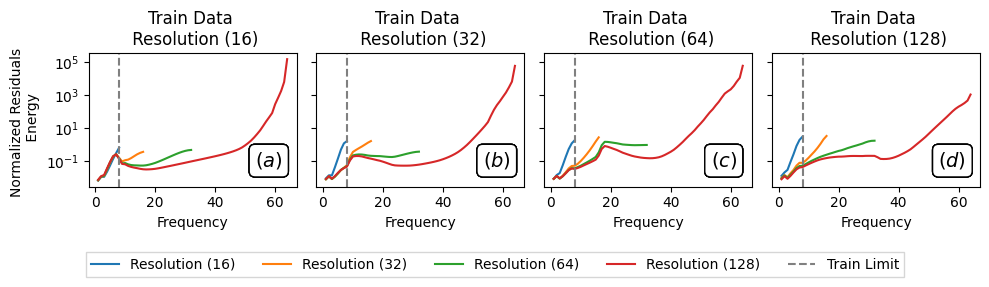

In [14]:
subplot_labels = ['a', 'b', 'c', 'd']

train_resolutions = [1, 0, 0, 0]
fig, axes = plt.subplots(
    nrows=1, ncols=4, sharey=True, sharex='col', figsize=(10, 2.5)
)

for x_idx, downsample_dim in enumerate(downsample_dims):
    model = trained_models[x_idx]

    # get data at various sizes
    for idx, test_down in enumerate(downsample_dims):
        # get filtered and downsampled test data
        data_transforms = transforms.Compose(
            [
                LowpassFilter(fixed_lim, 2),
                DownSample(test_down, 2),
            ]
        )
        train_dataloader, test_dataloaders = get_data(filename=file_name,
            saved_folder=data_folder,
            transform=data_transforms, 
            resolution_proportions=[1,0,0,0],
            test_res="single")
        test_loader = test_dataloaders["test"]

        # get unfiltered and downsampled test data
        data_transforms = transforms.Compose(
            [
                LowpassFilter(-1, 2), # don't filter
                DownSample(test_down, 2),
            ]
        )
        train_dataloader, test_dataloaders = get_data(filename=file_name,
            saved_folder=data_folder,
            transform=data_transforms, 
            resolution_proportions=[1,0,0,0],
            test_res="single")
        unfilter_test_loader = test_dataloaders["test"]
        

        # get model preds
        model_preds_test = get_model_preds(
            test_loader, model, device, initial_steps
        )
        offset = 0
        if initial_steps == 1:
            offset = 1
        labels = torch.concat(
            [
                test_loader.dataset[i]['y'][
                    :, initial_steps - offset :, ...
                ]
                for i in range(len(test_loader))
            ]
        )
        label_spectrum = get_energy_curve(labels)
        unfilter_labels = torch.concat(
            [
                unfilter_test_loader.dataset[i]['y'][
                    :, initial_steps - offset :, ...
                ]
                for i in range(len(unfilter_test_loader))
            ]
        )
        residuals = model_preds_test - labels.to(device)
        unfilter_label_spectrum = get_energy_curve(
            unfilter_labels
        )
        residual_spectrum = get_energy_curve(residuals)

        x = np.linspace(
            1, len(residual_spectrum), len(residual_spectrum)
        )
        axes[x_idx].set_yscale('log')
        d_dim = test_down
        if test_down == -1:
            d_dim = 128
        axes[x_idx].plot(
            x,
            residual_spectrum / unfilter_label_spectrum,
            # label=f'Downsample ({d_dim})',
            label=f'Resolution ({d_dim})',
        )
        axes[x_idx].annotate(
            f'$({subplot_labels[x_idx]})$',
            xy=(0.8, 0.15),
            xycoords='axes fraction',
            # textcoords='offset points',
            size=14,
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                edgecolor='black',
            ),
        )
        if idx == 3:
            axes[x_idx].axvline(
                x=fixed_lim,
                color='grey',
                linestyle='--',
                label='Train Limit',
            )
        d_dim = downsample_dim
        if downsample_dim == -1:
            d_dim = 128

        axes[x_idx].set_title(
            f'Train Data \n Resolution ({d_dim})'
        )
        axes[x_idx].set_xlabel('Frequency')
        if x_idx == 0:
            axes[x_idx].set_ylabel(
                'Normalized Residuals \n Energy'
            )
        handles, labels = axes[
            x_idx
        ].get_legend_handles_labels()

fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.0),
    fancybox=False,
    shadow=False,
    ncol=5,
)
plt.tight_layout()
plt.show()

# Information Extrapolation

Filter before downsampling. Assessing if models can accuratly extrapolate new frequencies in data that has fixed resolution.

In [15]:
img_size = 128
downsample_dim = -1
filter_lims = [8, 16, 32, -1]  # low-pass filter limits: 8, 16, 32, 64
max_mode = img_size // 2

trained_models = []
for filter_lim in filter_lims:
    # Handle data transformations
    data_transforms = transforms.Compose(
        [
            LowpassFilter(filter_lim, 2),
            DownSample(downsample_dim, 2),
        ]
    )

    train_dataloader, test_dataloaders = get_data(filename=file_name,
        saved_folder=data_folder,
        transform=data_transforms, 
        resolution_proportions=[1,0,0,0],
        test_res="single")

    model = get_fno(n_modes=max_mode)
    model = train_model(model, train_dataloader, test_dataloaders)
    trained_models.append(model)

self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [22:45<00:00,  9.05s/it, train_loss=9e-05 test=0.0004] 


self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [22:52<00:00,  9.09s/it, train_loss=7e-05 test=0.0003] 


self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [22:50<00:00,  9.07s/it, train_loss=7e-05 test=0.0004]


self.num_samples=9000
self.num_samples=1000


Training: 100%|██████████| 151/151 [21:37<00:00,  8.60s/it, train_loss=7e-05 test=0.0004] 


self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_samples=1000
self.num_samples=9000
self.num_s

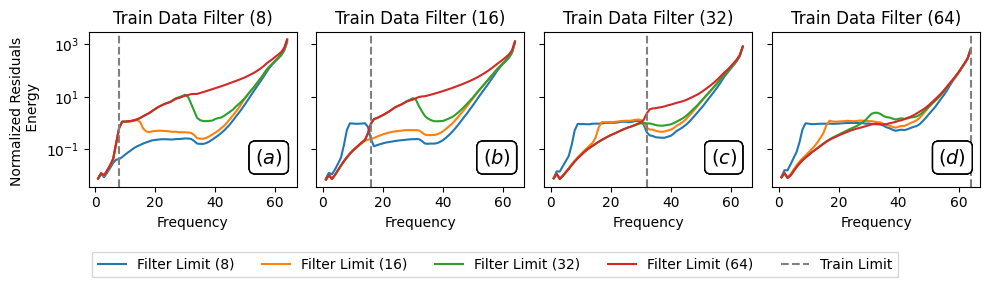

In [16]:
subplot_labels = ['a', 'b', 'c', 'd']

fig, axes = plt.subplots(
    nrows=1, ncols=4, sharey=True, sharex='col', figsize=(10, 2.5)
)

for x_idx, filter_lim in enumerate(filter_lims):
    if filter_lim == -1 and downsample_dim != -1:
        continue
    max_mode = max_modes[x_idx]
    model = trained_models[x_idx]

    # get data at various sizes
    for idx, test_filt in enumerate(filter_lims):
        # get filtered and downsampled test data
        data_transforms = transforms.Compose(
            [
                LowpassFilter(test_filt, 2),
                DownSample(-1, 2),
            ]
        )
    
        train_dataloader, test_dataloaders = get_data(filename=file_name,
            saved_folder=data_folder,
            transform=data_transforms, 
            resolution_proportions=[1,0,0,0],
            test_res="single")
        test_loader = test_dataloaders['test']

        # get unfiltered and downsampled test data
        data_transforms = transforms.Compose(
            [
                LowpassFilter(-1, 2), 
                DownSample(-1, 2), # don't downsampled
            ]
        )
    
        train_dataloader, test_dataloaders = get_data(filename=file_name,
            saved_folder=data_folder,
            transform=data_transforms, 
            resolution_proportions=[1,0,0,0],
            test_res="single")
        unfilter_test_loader = test_dataloaders['test']
        
        # get model preds
        model_preds_test = get_model_preds(
            test_loader, model, device, initial_steps
        )
        offset = 0
        if initial_steps == 1:
            offset = 1
        labels = torch.concat(
            [
                test_loader.dataset[i]['y'][
                    :, initial_steps - offset :, ...
                ]
                for i in range(len(test_loader))
            ]
        )
        unfilter_labels = torch.concat(
            [
                unfilter_test_loader.dataset[i]['y'][
                    :, initial_steps - offset :, ...
                ]
                for i in range(len(unfilter_test_loader))
            ]
        )
        residuals = model_preds_test - labels.to(device)
        unfilter_label_spectrum = get_energy_curve(
            unfilter_labels
        )
        residual_spectrum = get_energy_curve(residuals)

        x = np.linspace(
            1, len(residual_spectrum), len(residual_spectrum)
        )
        axes[x_idx].set_yscale('log')
        f_lim = test_filt
        if test_filt == -1:
            f_lim = max_mode
        axes[x_idx].plot(
            x,
            residual_spectrum / unfilter_label_spectrum,
            label=f'Filter Limit ({f_lim})',
        )

        axes[x_idx].annotate(
            f'$({subplot_labels[x_idx]})$',
            xy=(0.8, 0.15),
            xycoords='axes fraction',
            # textcoords='offset points',
            size=14,
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                edgecolor='black',
            ),
        )
        f_lim = filter_lim
        if filter_lim == -1:
            f_lim = max_mode
        if idx == 3:
            axes[x_idx].axvline(
                x=f_lim,
                color='grey',
                linestyle='--',
                label='Train Limit',
            )
        axes[x_idx].set_title(f'Train Data Filter ({f_lim})')
        axes[x_idx].set_xlabel('Frequency')
        if x_idx == 0:
            axes[x_idx].set_ylabel(
                'Normalized Residuals \n Energy'
            )
        handles, labels = axes[x_idx].get_legend_handles_labels()

fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.0),
    fancybox=False,
    shadow=False,
    ncol=5,
)
plt.tight_layout()
plt.show()

# Multi-Resolution Training

Train a model @ resolutions [16,32,64,128] (each resolution comprises 25% of dataset), test at resoluitons [16,32,64,128].
Visualize the average spectra across all 4 test sets.

In [17]:
model = get_fno(n_modes=64)
train_dataloader, test_dataloaders = get_data(filename=file_name,
        saved_folder=data_folder,
        transform=None, 
        resolution_proportions=[0.25,0.25,0.25,0.25],
        test_res="multi")

model = train_model(model, train_dataloader, test_dataloaders)

self.num_samples=9000
self.num_samples=1000
self.num_samples=1000
self.num_samples=1000
self.num_samples=1000


Training: 100%|██████████| 151/151 [09:20<00:00,  3.71s/it, train_loss=8e-05 test_res_0=0.0004 test_res_1=0.0004 test_res_2=0.0004 test_res_3=0.0004] 


self.num_samples=1000


/tmp/ipykernel_71525/2117437323.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  multi_res_aucs.append(abs(np.trapz(x, normalized_residuals).item()))


self.num_samples=1000
self.num_samples=1000
self.num_samples=1000


/tmp/ipykernel_71525/2117437323.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


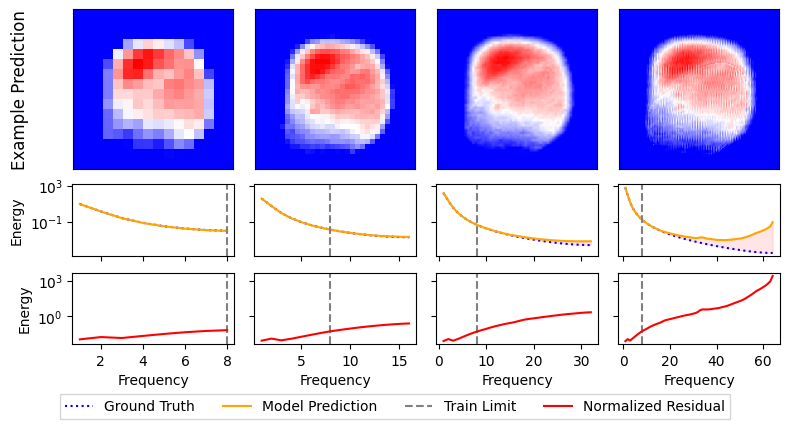

In [18]:
# fig, axs = plt.subplots(3, 4, figsize=(8, 8))

fig = plt.figure(layout='constrained', figsize=(8, 3.5))
subfigs = fig.subfigures(2, 1, wspace=0.07)  # three rows

img_axs = subfigs[0].subplots(1, 4, sharey=False)
spectrum_axs = subfigs[1].subplots(2, 4, sharey='row', sharex='col', gridspec_kw={'height_ratios': [1, 1]})
model = model.to(device)
model = model.eval()
multi_res_aucs = []

for x_idx, res in enumerate([16, 32, 64, 128]):
    resolution_ratio = [0, 0, 0, 0]
    resolution_ratio[-(x_idx + 1)] = 1
    resolutions = [16, 32, 64, 128]  # [128, 64, 32, 16]
    dataset = DarcyPDEBench(filename=file_name,
        saved_folder=data_folder,
        train=False,
        transform=None, 
        resolution_proportions=resolution_ratio,
        )
    # sample = dataset[0]
    sample = {
        'x': torch.concat([dataset[i]['x'] for i in range(len(dataset))]),
        'y': torch.concat([dataset[i]['y'] for i in range(len(dataset))]),
    }
    # grab a single input from the last batch
    model_input = sample['x'].to(device) 
    with torch.no_grad():
        model_output = model(x=model_input)
    ground_truth = sample['y']
    residuals = model_output - ground_truth.to(
        device
    )  

    # convert to plotable form
    model_in = model_input[0, 0, :, :].cpu().numpy()
    output = model_output[0, 0, :, :].cpu().numpy()
    label = ground_truth[0, 0, :, :].cpu().numpy()

    # get spectrums
    label_spectrum = get_energy_curve(ground_truth)
    pred_spectrum = get_energy_curve(model_output)
    residual_spectrum = get_energy_curve(residuals)

    img = output  # - label
    norm = colors.LogNorm(img.mean() + 0.5 * img.std(), img.max(), clip='True')
    img_axs[x_idx].imshow(img, norm=norm, cmap='bwr')

    img_axs[x_idx].get_yaxis().set_visible(False)
    img_axs[x_idx].get_xaxis().set_visible(False)
    subfigs[0].supylabel('Example Prediction')

    spectrum_axs[0,x_idx].set_yscale('log')
    spectrum_axs[1,x_idx].set_yscale('log')
    x = np.linspace(1, len(label_spectrum), len(label_spectrum))
    spectrum_axs[0,x_idx].plot(x, label_spectrum, label='Ground Truth', color="blue", ls=":")
    spectrum_axs[0,x_idx].plot(x, pred_spectrum, label='Model Prediction', color="orange")
    spectrum_axs[0,x_idx].fill_between(x, label_spectrum, pred_spectrum, color='red', alpha=0.1)
    spectrum_axs[0,x_idx].axvline(x=8, color='gray', linestyle='--', label="Train Limit")
    spectrum_axs[1,x_idx].axvline(x=8, color='gray', linestyle='--',) 
    normalized_residuals = residual_spectrum / label_spectrum
    spectrum_axs[1,x_idx].plot(
        x,
        normalized_residuals,
        label='Normalized Residual',
        color='red',
    )
    multi_res_aucs.append(abs(np.trapz(x, normalized_residuals).item()))
    spectrum_axs[0, 0].set_ylabel('Energy')
    spectrum_axs[1, 0].set_ylabel('Energy')
    spectrum_axs[1,x_idx].xaxis.set_major_locator(
        ticker.MaxNLocator(integer=True, nbins=4)
    )
    spectrum_axs[1,x_idx].set_xlabel('Frequency')


handles, labels = spectrum_axs[0,x_idx].get_legend_handles_labels()
_handles, _labels = spectrum_axs[1,x_idx].get_legend_handles_labels()
handles = handles + _handles
labels = labels + _labels
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fancybox=False,
    shadow=False,
    ncol=9,
)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/multi_{device}.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Multi-Res Training vs. Zero-shot Super Resolution

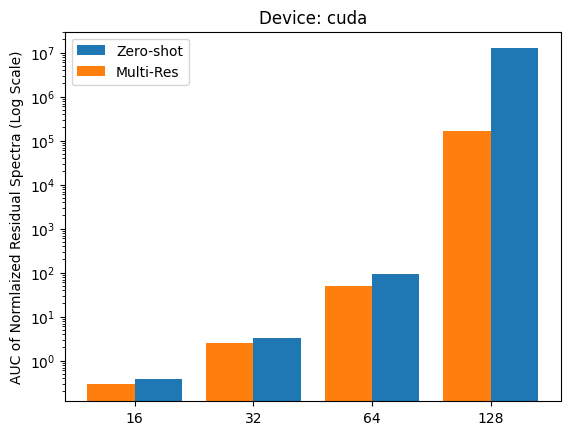

In [19]:
res = ['16', '32', '64', '128']
w = 0.4
x = np.array([1,2,3,4])

plt.bar(x + w/2, zero_shot_aucs, w, label='Zero-shot')
plt.bar(x - w/2, multi_res_aucs, w, label='Multi-Res')

plt.yscale('log')

plt.xticks(x, res)
plt.ylabel('AUC of Normlaized Residual Spectra (Log Scale)')
plt.title(f'Device: {device}')
plt.legend()
plt.savefig(f'{FIG_DIR}/multi_v_zero_{device}.pdf', bbox_inches='tight', dpi=300)
plt.show()